In [1]:
# from numba import cuda
import paicos as pa
import numpy as np
import cupy as cp
import turbocluster as tc
import math
from numba import cuda
import nvtx
import cmasher as cmr
import scipy.signal
# import finufft
%matplotlib widget

pa.settings.strict_units = False

# A snapshot object
# snap = pa.Snapshot(pa.data_dir, 247)
snap = pa.Snapshot('/llust21/cosmo-plasm/zoom-simulations-arepo2/halo_0003/tng/zoom12/output', 305, 
                   basename='snapshot')
# snap = pa.Snapshot('/lustre/astro/berlok/zoom-simulations-new-ics/halo_0003/tng/zoom12_ics_v1/output', 247)
center = snap.Cat.Group['GroupPos'][0]
widths = np.array([1000., 1000., 1000.], dtype=float)

# m_filter = 1000*snap.mass
# filter_length = (np.cbrt(3*m_filter/(4*np.pi*snap['0_Density']))).arepo
# filter_length = 2*snap['0_Diameters']




The default number of OpenMP threads, 8, exceeds the 1 available on your system. Setting numthreads=1. You can set numthreads with e.g. the command
 paicos.set_numthreads(16)




In [2]:
arepo_length = snap['0_Diameters'].uq
filter_length = 4*25*np.ones(snap['0_Diameters'].shape)*arepo_length
filter_type = 'gaussian'
nGrid = 256

Attempting to get derived variable: 0_Diameters...
	So we need the variable: 0_Volume...	[DONE]



In [3]:
# sf = tc.SmoothingFilter(snap, center, widths, npix=256, orientation=None, 
                        # search_radius=5.*filter_length.value)

In [4]:
depo = tc.DepositCartesianGrid(snap, center, widths, npoints=nGrid, threadsperblock=256, 
                               regionType='cartesian', kernel_type="PCS")

In [5]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize

widths_slicer = widths.copy()
widths_slicer[2] = 0.
slicer = pa.Slicer(snap, center, widths_slicer, 'z', npix=1024)
extent = slicer.centered_extent.to('Mpc')

In [6]:
@cuda.jit(lineinfo=True)
def _gpu_power_spectrum1d(vhat, kvec, Ngrid, Ncomplex, powerspectr):
    # vhat has shape: 
    # (Nx,Ny,Nz) if complex transform, or
    # (Nx,Ny,Nz//2+1) if real transform
    # Ngrid is a tuple with the dimension
    # of the real grid (Nx, Ny, Nz)
    # Ncomplex is a tuple with the dimension
    # of the complex grid:
    # (Nx, Ny, Nz) if C2C
    # (Nx, Ny, Nz//2+1) if R2C
    
    Nx, Ny, Nz = Ngrid
    ntotal = Nx*Ny*Nz
    ncomplex_kx, ncomplex_ky, ncomplex_kz = Ncomplex
    ntotal_complex = ncomplex_kx * ncomplex_ky * ncomplex_kz
    
    ip = cuda.grid(1)

    if (ip < ntotal_complex):
        k = ip % ncomplex_kz
        ip_tmp = int((ip - k)/ncomplex_kz)
        j = ip_tmp % ncomplex_ky
        i = ip_tmp // ncomplex_ky
    
        # kx =  ( i +  float(Nx) / 2.0) %  Nx  - Nx / 2 
        # ky =  ( j +  float(Ny) / 2.0) %  Ny  - Ny / 2 
        # if (ncomplex_kz == Nz//2 + 1):
        #     kz = k
        # else:
        #     kz =  ( k +  float(Nz) / 2.0) %  Nz  - Nz / 2 

        # # this is to take into account that 
        # # the widths of the region can be different
        # # but the Ny,Nz are chosen such that
        # # the spacing is uniform in all 3 directions
        # ky *= Nx / Ny
        # kz *= Nx / Nz

        power_at_freq = (vhat[i,j,k] * vhat[i,j,k].conjugate() ).real
        
        freq = int(kvec[i,j,k] + 0.5)
        # # if we are doing a real fft
        # # we need to double to take into account
        # # energy contained in the negative KZ midplane
        if (k > 0 and (ncomplex_kz - 1) % (Nz//2) == 0): 
        # if (k > 0):
            power_at_freq *= 2.0
    
        # powerspectr[0,0,0] = i
        # cuda.atomic.add(powerspectr, (freq), 
        #                 power_at_freq / ((Nx*Ny*Nz)**2))
        cuda.atomic.add(powerspectr, (freq), 
                        power_at_freq / (ntotal**2))

@cuda.jit(lineinfo=True)
def _gpu_power_spectrum1d_finufft(vhat, kvec, Ngrid, Ncomplex, powerspectr, M):
    # vhat has shape: 
    # (Nx,Ny,Nz) if complex transform, or
    # (Nx,Ny,Nz//2+1) if real transform
    # Ngrid is a tuple with the dimension
    # of the real grid (Nx, Ny, Nz)
    # Ncomplex is a tuple with the dimension
    # of the complex grid:
    # (Nx, Ny, Nz) if C2C
    # (Nx, Ny, Nz//2+1) if R2C
    # M is the original length of the sampling points in finufft
    
    Nx, Ny, Nz = Ngrid
    ntotal = Nx*Ny*Nz
    ncomplex_kx, ncomplex_ky, ncomplex_kz = Ncomplex
    ntotal_complex = ncomplex_kx * ncomplex_ky * ncomplex_kz
    
    ip = cuda.grid(1)

    if (ip < ntotal_complex):
        k = ip % ncomplex_kz
        ip_tmp = int((ip - k)/ncomplex_kz)
        j = ip_tmp % ncomplex_ky
        i = ip_tmp // ncomplex_ky
    
        # kx =  ( i +  float(Nx) / 2.0) %  Nx  - Nx / 2 
        # ky =  ( j +  float(Ny) / 2.0) %  Ny  - Ny / 2 
        # if (ncomplex_kz == Nz//2 + 1):
        #     kz = k
        # else:
        #     kz =  ( k +  float(Nz) / 2.0) %  Nz  - Nz / 2 

        # # this is to take into account that 
        # # the widths of the region can be different
        # # but the Ny,Nz are chosen such that
        # # the spacing is uniform in all 3 directions
        # ky *= Nx / Ny
        # kz *= Nx / Nz

        power_at_freq = (vhat[i,j,k] * vhat[i,j,k].conjugate() ).real
        
        freq = int(kvec[i,j,k] + 0.5)
        # # if we are doing a real fft
        # # we need to double to take into account
        # # energy contained in the negative KZ midplane
        if (k > 0 and (ncomplex_kz - 1) % (Nz//2) == 0): 
        # if (k > 0):
            power_at_freq *= 2.0
    
        # powerspectr[0,0,0] = i
        # cuda.atomic.add(powerspectr, (freq), 
        #                 power_at_freq / ((Nx*Ny*Nz)**2))
        cuda.atomic.add(powerspectr, (freq), 
                        power_at_freq / (M**2))
        
def power_spectrum1d_gpu(KX, KY, KZ, vhat, Ngrid, Lx, finufft=False, M=-1):
    # vhat and KX, KY, KZ have the same shape: 
    # (Nx,Ny,Nz) if complex transform, or
    # (Nx,Ny,Nz//2+1) if real transform
    # Ngrid is a tuple with the dimension
    # of the real grid (Nx, Ny, Nz)
    Nx, Ny, Nz = Ngrid
    Ntotalcomplex = vhat.shape[0]*vhat.shape[1]*vhat.shape[2]

    if (finufft and M==-1):
        raise RuntimeError('The length of the original signal \
        has to be set')

    kvec = np.sqrt(KX**2 + KY**2 + KZ**2)

    kxmax = Nx/2
    kymax = kxmax
    kzmax = kxmax

    kmax = int(np.sqrt(kxmax**2 + kymax**2 + kzmax**2) + 0.5)
    kmin = 0
    k1d = np.arange(kmin, kmax+1)

    d_vhat = cp.array(vhat)
    d_kvec = cp.array(kvec)
    d_powerspectr = cp.zeros(k1d.shape)
    threadsperblock = 256
    blocks_1d = (Ntotalcomplex + (threadsperblock - 1)) // threadsperblock

    if not finufft:
        _gpu_power_spectrum1d[blocks_1d, threadsperblock](d_vhat, d_kvec, (Nx, Ny, Nz), 
                                                      (vhat.shape[0], vhat.shape[1], vhat.shape[2]), 
                                                      d_powerspectr)
    else:
        _gpu_power_spectrum1d_finufft[blocks_1d, threadsperblock](d_vhat, d_kvec, (Nx, Ny, Nz), 
                                                      (vhat.shape[0], vhat.shape[1], vhat.shape[2]), 
                                                      d_powerspectr, M)
    
    return cp.asnumpy(d_powerspectr), k1d*(2.0*np.pi/Lx)

In [7]:
def _nd_window(data, filter_function):
    """
    https://stackoverflow.com/questions/27345861/extending-1d-function-across-3-dimensions-for-data-windowing
    Performs an in-place windowing on N-dimensional spatial-domain data.
    This is done to mitigate boundary effects in the FFT.

    Parameters
    ----------
    data : ndarray
           Input data to be windowed, modified in place.
    filter_function : 1D window generation function
           Function should accept one argument: the window length.
           Example: scipy.signal.windows.hann
    """
    windowed_data = data.value.copy()
    ndim_window = np.ones_like(data)
    for axis, axis_size in enumerate(data.shape):
        # set up shape for numpy broadcasting
        filter_shape = [1, ] * data.ndim
        filter_shape[axis] = axis_size
        window = filter_function(axis_size).reshape(filter_shape)
        # scale the window intensities to maintain image intensity
        # np.power(window, (1.0/data.ndim), out=window)
        window = window**(1.0/data.ndim)
        windowed_data *= window
        ndim_window *= window
    
    # norm_coeff = np.sqrt(np.sum(np.square(np.abs(ndim_window))))
    return windowed_data * data.unit_quantity, ndim_window

In [8]:
# this is the relative *turbulent* density fluctuation

Nx, Ny, Nz = depo.npoints.tolist()

# here d is the same for all because the 
# cartesian grid is created such that each 
# cell has Delta x = Delta y = Delta x
kx = np.fft.fftfreq(Nx, d=1.0/Nx)
ky = np.fft.fftfreq(Ny, d=1.0/Nx)
kz = np.fft.rfftfreq(Nz, d=1.0/Nx)

# By multiplying kx, ky, kz by (2.0 pi / L_x)
# we get physical wavenumbers (1/length)
Lx = depo.widths[0]

KX, KY, KZ = np.meshgrid(kx, ky, kz, indexing='ij')
# hat_turb_rel_den = np.fft.rfftn(turb_rel_density_cartesian)
# powerspectr, k1d = power_spectrum1d_gpu(KX, KY, KZ, hat_turb_rel_den, (Nx,Ny,Nz), Lx)

In [9]:
# with twice the original resolution

depo_HR = tc.DepositCartesianGrid(snap, center, widths, npoints=2*nGrid, threadsperblock=256, 
                               regionType='cartesian', kernel_type="PCS")

# turb_rel_density_cartesian_HR = depo_HR.deposit_variable('0_RelTurbDens', 
#                                                          weight='0_Volume')


Nx_HR, Ny_HR, Nz_HR = depo_HR.npixs.tolist()
# here d is the same for all because the 
# cartesian grid is created such that each 
# cell has Delta x = Delta y = Delta x
kx_HR = np.fft.fftfreq(Nx_HR, d=1.0/Nx_HR)
ky_HR = np.fft.fftfreq(Ny_HR, d=1.0/Nx_HR)
kz_HR = np.fft.rfftfreq(Nz_HR, d=1.0/Nx_HR)
# By multiplying kx, ky, kz by (2.0 pi / L_x)
# we get physical wavenumbers (1/length)
Lx = depo_HR.widths[0]
KX_HR, KY_HR, KZ_HR = np.meshgrid(kx_HR, ky_HR, kz_HR, indexing='ij')
# hat_turb_rel_den_HR = np.fft.rfftn(turb_rel_density_cartesian_HR)


# powerspectr_HR, k1d_HR = power_spectrum1d_gpu(KX_HR, KY_HR, KZ_HR, 
#                                               hat_turb_rel_den_HR, (Nx_HR,Ny_HR,Nz_HR), Lx)

In [10]:
# this is the total density 
density_cartesian = depo.deposit_variable('0_Density', weight='0_Volume')
hat_den = np.fft.rfftn(density_cartesian)
powerspectr_rho, k1d = power_spectrum1d_gpu(KX, KY, KZ, hat_den, 
                                                  (Nx,Ny,Nz), Lx)

/home/lperrone/miniforge3/envs/paicos-conda/lib/python3.11/site-packages/numba/core/lowering.py:112: NumbaDebugInfoWarning: Could not find source for function: <function _gpu_power_spectrum1d at 0x7f3819cca980>. Debug line information may be inaccurate.
  warnings.warn(NumbaDebugInfoWarning(msg))


In [11]:
# this is the total density but with twice the 
# original resolution
density_cartesian_HR = depo_HR.deposit_variable('0_Density', weight='0_Volume')
hat_den_HR = np.fft.rfftn(density_cartesian_HR)
powerspectr_rho_HR, k1d_HR = power_spectrum1d_gpu(KX_HR, KY_HR, KZ_HR, hat_den_HR, 
                                                  (Nx_HR,Ny_HR,Nz_HR), Lx)

In [30]:
# powerspectr_rho_finufft, k1d = power_spectrum1d_gpu(KKX, KKY, KKZ, hat_density_finufft/len(x), 
#                                                 (Nx,Ny,Nz), Lx, finufft=True, M=np.sqrt(len(x)))

In [3]:
depo_TSC = tc.DepositCartesianGrid(snap, center, widths, npoints=nGrid, threadsperblock=256, 
                               regionType='cartesian', kernel_type="TSC")



In [12]:
# this is the total density 
density_cartesian_TSC = depo_TSC.deposit_variable('0_Density', weight='0_Volume')
hat_den_TSC = np.fft.rfftn(density_cartesian_TSC)
powerspectr_rho_TSC, k1d = power_spectrum1d_gpu(KX, KY, KZ, hat_den_TSC, 
                                                  (Nx,Ny,Nz), Lx)



In [13]:
depo_HR_TSC = tc.DepositCartesianGrid(snap, center, widths, npoints=2*nGrid, threadsperblock=256, 
                               regionType='cartesian', kernel_type="TSC")

In [14]:
# this is the total density but with twice the 
# original resolution
density_cartesian_HR_TSC = depo_HR_TSC.deposit_variable('0_Density', weight='0_Volume')
hat_den_HR_TSC = np.fft.rfftn(density_cartesian_HR_TSC)
powerspectr_rho_HR_TSC, k1d_HR = power_spectrum1d_gpu(KX_HR, KY_HR, KZ_HR, hat_den_HR_TSC, 
                                                  (Nx_HR,Ny_HR,Nz_HR), Lx)

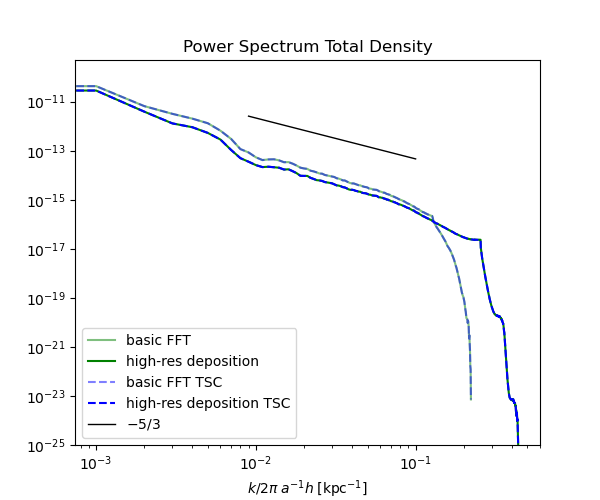

In [16]:
fig, ax = plt.subplots(figsize=(6,5))
t = np.logspace(np.log10(9e-3),np.log10(1e-1), 100)

ax.plot(k1d.astro/(2.0*np.pi), powerspectr_rho, ls='-', color='g', label='basic FFT', alpha=0.5)

ax.plot(k1d_HR.astro/(2.0*np.pi), powerspectr_rho_HR, ls='-', markersize=4, color='g',label='high-res deposition')


ax.plot(k1d.astro/(2.0*np.pi), powerspectr_rho_TSC, ls='--', color='b', label='basic FFT TSC', alpha=0.5)

ax.plot(k1d_HR.astro/(2.0*np.pi), powerspectr_rho_HR_TSC, ls='--',  markersize=4, color='b',label='high-res deposition TSC')

# ax.plot(k1d.astro/(2.0*np.pi), powerspectr_rho_finufft, ls='-', marker='s', 
#         markerfacecolor='none', markersize=4, color='r',label='finuFFT')


ax.plot(t, 1e-15*t**(-5./3.), ls='-', color='k',label=r'$-5/3$',lw=1.)
# ax.plot(k1d_padded, powerspectr_padded, ls='-', marker='d', markerfacecolor='none', 
        # color='r', markersize=4, label='zero-pad FFT (3)')
# ax.plot(k1d, powerspectr_nonrel*1e9, ls='-', marker='^', color='orange',markerfacecolor='none', 
        # markersize=4, label='simple FFT nonrel (x1e9)')

# ax.plot(k1d_uniform, powerspectr_ngp, ls='', marker='^', color='orange', markerfacecolor='none', markersize=4, label='np.fft ngp')
# ax.plot(k1d_uniform, powerspectr_cic, ls='', marker='x', color='g', markerfacecolor='none', markersize=4, label='np.fft cic')

# ax.set_xlabel('|k|')
ax.set_xlabel(k1d.astro.label('k / 2 \\pi'))
ax.set_xscale('log')
ax.set_yscale('log')

ax.legend()

ax.set_title(r'Power Spectrum Total Density')


ax.set_ylim(ymin=1e-25)
# ax.set_ylim(ymin=1e-10)
# ax[1].set_xlim(xmax=30)
plt.savefig('../plots/deposit-kernel/power_spectra_TSC_PCS_comparison.pdf',dpi=400)

plt.show()
